In [76]:

import pandas as pd

print("Setup successful!")

Setup successful!


In [77]:
import pandas as pd

file1 = pd.read_excel("Book1.xlsx")
file2 = pd.read_excel("Data.xlsx")
## checking both the files structure
print("File 1 Shape:", file1.shape)
print("File 2 Shape:", file2.shape)

File 1 Shape: (212, 12)
File 2 Shape: (141, 13)


In [78]:
##extra column
set(file2.columns) - set(file1.columns)

{'S NO'}

In [79]:
##drop column "S NO"
file2 = file2.drop(columns=["S NO"])

In [80]:
##verifying the structure alignment
print(file1.shape)
print(file2.shape)

(212, 12)
(141, 12)


In [81]:
## checking column order
print(file1.columns.tolist())
print(file2.columns.tolist())

['Timestamp', 'Patient Name', 'Gender', 'Email', 'Age', 'Address', 'Phone number', 'Alternate phone Number', 'Date of Birth', 'Date of Visiting', 'Occupation', 'Disease']
['Timestamp', 'Patient Name', 'Gender', 'Email', 'Age', 'Address', 'Phone number', 'Alternate phone Number', 'Date of Birth', 'Date of Visiting', 'Occupation', 'Disease']


In [82]:
##Create master sheet(merging both excel sheet)
master = pd.concat([file1, file2], ignore_index=True)

print(master.shape)

(353, 12)


In [83]:
##Check number of duplicate records
master.duplicated().sum()

np.int64(142)

In [84]:
##checking duplicate rows
duplicates = master[master.duplicated()]

duplicates.head(10)

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212,2026-11-02 09:08:19,Bhupendra Singh Gaur,Male,bsgaur1972@gmail.com,54.0,"65-B TELEPHONE NAGAR, KISHANGANJ, MHOW",9993120045,9926092558,7/13/1972,1/20/2026,Pensioner Defence,Spine Proublem
213,2026-11-02 09:23:22,Lakhan Dave,Male,NaN,26.0,"112, Krishna vihar colony chota bangarda indore",9109443823,8435089895,1998-11-09 00:00:00,2026-11-02 00:00:00,Job,Cervical neck pain
214,2026-11-02 09:25:30,Sulochana tejwani,Female,sakshitejwani111@gmail.com,62.0,111 kranti kriplani nagar,8319724909,9303911377,4/22/1966,2026-11-02 00:00:00,Homemaker,Knee pain
215,2026-11-02 09:28:35,Jayshree Patil,Female,patil.subash1962@gmail.com,56.0,Mahu gaon,9755808879,6266115377,4/16/1970,2026-11-02 00:00:00,Retired,Back bone
216,2026-11-02 09:32:32,Priti Agrawal,Female,krish11.agrawal@gmail.com,46.0,7 Maa Durga Nagar,7987495048,9302061193,6/21/1980,2026-11-02 00:00:00,Housewife,Slip disc
217,2026-11-02 09:34:17,Sakina Barudwala,Female,asgeralibaroodwala@gmail.com,50.0,Mandsaur,9407447311,9407447311,1976-01-01 00:00:00,2026-11-02 00:00:00,House wife,Backbone
218,2026-11-02 09:39:54,Asger Ali,Male,sakinabarood086@gmail.com,55.0,Mandsaur,9424098265,9424098265,12/15/1967,2026-11-02 00:00:00,Business,Back Bone
219,2026-11-02 09:50:13,Prashant singh,Male,parshant.83.in@gmail.com,42.0,101 shiv city indore,9691952644,9111030033,2026-11-02 00:00:00,2026-12-02 00:00:00,Self employed,Shoulder pain
220,2026-11-02 09:52:01,Himani Khandelwal,Female,NaN,29.0,"28/E Sadhna Nagar, Airport Road, Indore",9165819193,9827032337,5/22/1996,2026-11-02 00:00:00,Business,Back Pain


In [85]:
##checking completely blank rows
master[master.isnull().all(axis=1)]

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
##count of empty rows
master[master.isnull().all(axis=1)].shape


(2, 12)

In [87]:
##remove blank rows
master = master.dropna(how="all")

In [88]:
##verification
master.shape

(351, 12)

In [89]:
##recheck duplicates
master.duplicated().sum()

np.int64(141)

In [90]:
##checking the duplicate groups
duplicates = master[master.duplicated(keep=False)]

duplicates.head(20)

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease
0,2026-11-02 09:08:19,Bhupendra Singh Gaur,Male,bsgaur1972@gmail.com,54,"65-B TELEPHONE NAGAR, KISHANGANJ, MHOW",9993120045,9926092558,7/13/1972,1/20/2026,Pensioner Defence,Spine Proublem
1,2026-11-02 09:23:22,Lakhan Dave,Male,NaN,26,"112, Krishna vihar colony chota bangarda indore",9109443823,8435089895,1998-11-09 00:00:00,2026-11-02 00:00:00,Job,Cervical neck pain
2,2026-11-02 09:25:30,Sulochana tejwani,Female,sakshitejwani111@gmail.com,62,111 kranti kriplani nagar,8319724909,9303911377,4/22/1966,2026-11-02 00:00:00,Homemaker,Knee pain
3,2026-11-02 09:28:35,Jayshree Patil,Female,patil.subash1962@gmail.com,56,Mahu gaon,9755808879,6266115377,4/16/1970,2026-11-02 00:00:00,Retired,Back bone
4,2026-11-02 09:32:32,Priti Agrawal,Female,krish11.agrawal@gmail.com,46,7 Maa Durga Nagar,7987495048,9302061193,6/21/1980,2026-11-02 00:00:00,Housewife,Slip disc
5,2026-11-02 09:34:17,Sakina Barudwala,Female,asgeralibaroodwala@gmail.com,50,Mandsaur,9407447311,9407447311,1976-01-01 00:00:00,2026-11-02 00:00:00,House wife,Backbone
6,2026-11-02 09:39:54,Asger Ali,Male,sakinabarood086@gmail.com,55,Mandsaur,9424098265,9424098265,12/15/1967,2026-11-02 00:00:00,Business,Back Bone
7,2026-11-02 09:50:13,Prashant singh,Male,parshant.83.in@gmail.com,42,101 shiv city indore,9691952644,9111030033,2026-11-02 00:00:00,2026-12-02 00:00:00,Self employed,Shoulder pain
8,2026-11-02 09:52:01,Himani Khandelwal,Female,NaN,29,"28/E Sadhna Nagar, Airport Road, Indore",9165819193,9827032337,5/22/1996,2026-11-02 00:00:00,Business,Back Pain
9,2026-11-02 10:25:37,Maya Raikwar,Female,Visit.shashank0724@gmail.com,55,"106, Bank Colony, Annapurna Road, Opposite Dus...",7415077724,9144444247,1969-07-02 00:00:00,2026-11-02 00:00:00,House maker,Cervical pain


In [91]:
##confirming the duplicate rows
master[master["Patient Name"] == "Pratima Jadon"]

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease
18,2026-11-02 11:51:06,Pratima Jadon,Female,bondilldombill@gmail.com,52,"E 506, Silver Springs Phase 1\nNayta Mundla, A...",7024453559,7875447333,1974-08-01 00:00:00,2016-11-02 00:00:00,Interior Designer,"Lower backache, cervical, nerve compress"
230,2026-11-02 11:51:06,Pratima Jadon,Female,bondilldombill@gmail.com,52.0,"E 506, Silver Springs Phase 1\nNayta Mundla, A...",7024453559,7875447333,1974-08-01 00:00:00,2016-11-02 00:00:00,Interior Designer,"Lower backache, cervical, nerve compress"


In [92]:
##droping the duplicates
master = master.drop_duplicates()

In [93]:
##verifcation of structure of data
master.shape

(210, 12)

In [94]:
##missing value analysis
master.isnull().sum()

Timestamp                 16
Patient Name               0
Gender                     0
Email                     55
Age                        4
Address                    1
Phone number               0
Alternate phone Number     0
Date of Birth              9
Date of Visiting           7
Occupation                 4
Disease                    4
dtype: int64

In [95]:
##filling the missing values

##Address
master["Address"] = master["Address"].fillna("Unknown")

##occupation
master["Occupation"] = master["Occupation"].fillna("Not Mentioned")




In [96]:
##missing value-age


##if DOB exist
today = pd.Timestamp.today()

master.loc[master["Age"].isnull(), "Age"] = (
    (today - pd.to_datetime(master.loc[master["Age"].isnull(), "Date of Birth"]))
    .dt.days // 365
)

##check age column
master["Age"].unique()

##convert age into numeric values
master["Age"] = pd.to_numeric(master["Age"], errors="coerce")

##find unrealistic value
master[master["Age"] > 120]

##replace unrealistic ages with missing values
master.loc[master["Age"] > 120, "Age"] = pd.NA

##check missing ages again
master[master["Age"].isnull()]

##check again if DOB exist
master.loc[
    master["Age"].isnull(),
    ["Patient Name", "Age", "Date of Birth"]
]

##fill the remaining null age with median
master["Age"] = master["Age"].fillna(master["Age"].median())



In [97]:
##disease
master[master["Disease"].isnull()]

##fill missing disease with not recorded
master["Disease"] = master["Disease"].fillna("Not Recorded")

##DOB missing values
##estimating DOB from age
from datetime import datetime

current_year = datetime.now().year

master.loc[
    master["Date of Birth"].isnull(),
    "Date of Birth"
] = pd.to_datetime(
    (current_year - master["Age"]).astype(int).astype(str) + "-01-01"
)

Missing Date of Birth values were estimated using Age and a default date of January 1st

In [98]:
##Date of visiting
master[master["Date of Visiting"].isnull()]

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease
200,NaN,komal ochani,femle,komalochani26@gmail.com,40.0,sindhi colony,9200580123,9200580123,1989-11-26 00:00:00,NaN,house wife,slipdisk
201,NaN,jyoti gara,female,NaN,54.0,Unknown,9399168248,9399168248,1971-07-27 00:00:00,NaN,house wife,legs and knee
202,NaN,shubhash saraf,femle,NaN,47.5,mundi khandwa,9993109223,9993109223,1978-01-01 00:00:00,NaN,sarivice,back pain
203,NaN,rakhi modi,female,NaN,50.0,silicone city,9893066960,9893066960,1976-01-01 00:00:00,NaN,house wife,hand pain
204,NaN,leena paryani,female,NaN,45.0,indore,9893066960,9893066960,1981-11-12 00:00:00,NaN,house wife,legs and knee pain
205,NaN,sandhya,female,NaN,29.0,mahu,9589909712,9589909712,1997-01-01 00:00:00,NaN,farmer,back pain
206,NaN,neeraj singh thakur,male,NaN,33.0,dewas,9713608053,9713608053,1993-07-23 00:00:00,NaN,auto driver,back pain


Cleaning Summary

Original Records: 353
Blank Rows Removed: 2
Duplicate Records Removed: 141
Final Records: 210

Missing Values Remaining:
- Email: 55
- Timestamp: 16
- Date of Visiting: 7

Reason:
These fields could not be reliably recovered from existing data and were left missing to maintain data integrity.

In [99]:
##standardizing and formatting data

##Gender
master["Gender"].value_counts()
master["Gender"] = master["Gender"].str.title()
master["Gender"] = master["Gender"].replace({
    "Femle": "Female"
})

##patient name
master["Patient Name"] = master["Patient Name"].str.title().str.strip()

##Address
master["Address"] = master["Address"].str.strip()

##disease
master["Disease"].value_counts()
master["Disease"] = master["Disease"].str.title()
master["Disease"] = master["Disease"].replace({"Slip Disk":"Slip Disc"})
master["Disease"] = master["Disease"].replace({
    "Arthridis": "Arthritis"
})

##disease names
disease_list = sorted(master["Disease"].dropna().unique())


##standardizing disease dictionary
master["Disease"] = master["Disease"].replace({
    
    # Back Pain
    "Backpain": "Back Pain",
    "Back Pan": "Back Pain",
    "Back Pen": "Back Pain",
    "Bake Pain": "Back Pain",
    "Back Pain'": "Back Pain",

    # Slip Disc
    "Slipdisc": "Slip Disc",
    "Slipdisk": "Slip Disc",
    "Slipped Disc": "Slip Disc",
    "Slip Disc Problem": "Slip Disc",

    # Sciatica
    "Sitica": "Sciatica",
    "Sietika": "Sciatica",
    "Saitica": "Sciatica",

    # Cervical
    "Servical": "Cervical Pain",
    "Survical": "Cervical Pain",
    "Cirvical": "Cervical Pain",
    "Cervical Neck Pain": "Cervical Pain"
})    

In [100]:
disease_list = sorted(master["Disease"].dropna().unique())

for disease in disease_list:
    print(disease)

##count
master["Disease"].value_counts()

##create a new column "Disease_Category"] = "Other"

##group similar diseases
master.loc[
    master["Disease"].str.contains("Back", case=False, na=False),
    "Disease_Category"
] = "Back Pain"

master.loc[
    master["Disease"].str.contains("Knee", case=False, na=False),
    "Disease_Category"
] = "Knee Pain"

master.loc[
    master["Disease"].str.contains("Cervical", case=False, na=False),
    "Disease_Category"
] = "Cervical"

master.loc[
    master["Disease"].str.contains("Slip", case=False, na=False),
    "Disease_Category"
] = "Slip Disc"

master.loc[
    master["Disease"].str.contains("Sciatica|Sitica|Sietika", case=False, na=False),
    "Disease_Category"
] = "Sciatica"



##Count Categories
master["Disease_Category"].value_counts()



Acidity
Ankle Sprain
Arm Pain
Arthritis
As
Avn
Avn At Hip Joint
B/L Knee Joint Pain
B/L Knee Pain
Back & Knee Pain
Back & Shoulder Pain
Back , Knee Pain
Back , Neck, Shoulder Pain
Back , Spine, Ankle
Back Bone
Back Issues
Back Pain
Back Pain + Lever Detox
Back Pain And Cervical
Back Pain And Left Leg Ppain
Back Pain Slip Disk
Back Pain Spondylysis
Back Pain Treatment
Back Pin And Neck Pain
Backbone
Backbone Pain
Bek Pen
Body Pain
Body Pain And Weakness
Cervical Injury
Cervical Pain
Cirvacal
Costochondritis
Disc Issue
Disc Prolapse L5 S1
Disk Bulge.
Fever
Frojan Shoulader
Gathia Problem
Hand Fracture
Hand Issue
Hand Pain
Head Pain
Headache
Hemangioma
Inflammation
Knee Pain
Knee Pain And Sciatica
Knee Problem
L4 & L5
L4 /L5 (Slip Disk)
L4 L5. And Cervical C4-C5
L5
Left Body Pain
Leg And Back Pain
Leg Pain
Leg Pain And Swelling
Leg Pan
Legs And Knee
Legs And Knee Pain
Ligament Problems
Lower Back Pain
Lower Backache, Cervical, Nerve Compress
Lower Backpain
Lumber Spine Mid
Mnd
Multiple Jo

Disease_Category
Back Pain    69
Knee Pain    26
Slip Disc    20
Cervical      9
Sciatica      5
Name: count, dtype: int64

a new column named "Disease_Category" as been created to store the disease categories.

In [101]:
##Occupation

##standardizing
master["Occupation"] = (
    master["Occupation"]
    .astype(str)
    .str.strip()
    .str.title()
)  

##count
master["Occupation"].value_counts()

##mapping
master["Occupation"] = master["Occupation"].replace({

    # Housewife group
    "Housewife": "House Wife",
    "House Women": "House Wife",
    "Home Maker": "House Wife",
    "Homemaker": "House Wife",
    "Housemaker": "House Wife",
    "Hous Wife": "House Wife",
    "House Maker": "House Wife",
    "House Head": "House Wife",

    # Business group
    "Buisness": "Business",
    "Business Owner": "Business",
    "Business Women": "Business",
    "Businessman": "Business",
    "Cotton Bussiness": "Business",

    # Government Service group
    "Government Servent": "Government Service",
    "Govt Job": "Government Service",
    "Govt Service": "Government Service",
    "Govt.Teacher": "Government Service",

    # Service group
    "Private Job": "Service",
    "Private Sector": "Service",
    "Salary Emp.": "Service",
    "Salaried": "Service",
    "Sarivice": "Service",
    "Working": "Service",
    "Wark": "Service",
    "Job": "Service",

    # Teaching group
    "Teachers": "Teacher",
    "Teachings": "Teacher",
    "Lecturer": "Teacher",
    "Professor": "Teacher",

    # IT group
    "Software Developer": "IT Professional",
    "Software Engineer": "IT Professional",
    "It/Software Engineering": "IT Professional",

    # Retirement group
    "Pensioner Defence": "Retired",

    # Missing values group
    "Nothing": "Not Mentioned",
    "रिटायर्ड": "Retired"
})


##rectifying data
master[master["Occupation"] == "Back Pain"]

master.loc[
    master["Occupation"] == "Back Pain",
    "Occupation"
] = "Not Mentioned"

##print unique occupations
occupation_list = sorted(master["Occupation"].dropna().unique())
for occ in occupation_list:
    print(occ)

##merging similar occupation
master["Occupation"] = master["Occupation"].replace({

    # Service group
    "Salary Emp.": "Service",
    "Employed": "Service",
    "Service Sunpharma": "Service",

    # Business group
    "Self Employed": "Business",

    # Teaching group
    "Tuition": "Teacher"
})    

##check
master["Occupation"].value_counts().head(20)

Accountant
Auto Driver
Bakery Work
Business
Carpenter
Construction
Employed
Farmer
Finance
Freelance
Government Service
House Wife
IT Professional
Interior Designer
Majduri
Makeup Artist
Milk Man
Not Mentioned
Nutritionist And Health Consultant
Officer In Pharmaceutics
Police
Professional
Real Estate
Retired
Sallary Emp.
Self Employed
Service
Service Sunpharma
Shopkeeper
Student
Tailor
Teacher
Tuition


Occupation
House Wife                  105
Business                     23
Service                      18
Farmer                       11
Student                       7
Not Mentioned                 7
Teacher                       6
Retired                       5
Government Service            4
IT Professional               4
Accountant                    2
Sallary Emp.                  1
Interior Designer             1
Professional                  1
Finance                       1
Freelance                     1
Officer In Pharmaceutics      1
Construction                  1
Tailor                        1
Makeup Artist                 1
Name: count, dtype: int64

In [102]:
##data type
master.dtypes

Timestamp                  object
Patient Name               object
Gender                     object
Email                      object
Age                       float64
Address                    object
Phone number               object
Alternate phone Number     object
Date of Birth              object
Date of Visiting           object
Occupation                 object
Disease                    object
Disease_Category           object
dtype: object

In [103]:
master[
    ["Timestamp", "Date of Birth", "Date of Visiting"]
].head(15)

,Timestamp,Date of Birth,Date of Visiting
0,2026-11-02 09:08:19,7/13/1972,1/20/2026
1,2026-11-02 09:23:22,1998-11-09 00:00:00,2026-11-02 00:00:00
2,2026-11-02 09:25:30,4/22/1966,2026-11-02 00:00:00
3,2026-11-02 09:28:35,4/16/1970,2026-11-02 00:00:00
4,2026-11-02 09:32:32,6/21/1980,2026-11-02 00:00:00
5,2026-11-02 09:34:17,1976-01-01 00:00:00,2026-11-02 00:00:00
6,2026-11-02 09:39:54,12/15/1967,2026-11-02 00:00:00
7,2026-11-02 09:50:13,2026-11-02 00:00:00,2026-12-02 00:00:00
8,2026-11-02 09:52:01,5/22/1996,2026-11-02 00:00:00
9,2026-11-02 10:25:37,1969-07-02 00:00:00,2026-11-02 00:00:00


In [104]:
##formatting
master["Date of Birth"] = pd.to_datetime(
    master["Date of Birth"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

master["Date of Visiting"] = pd.to_datetime(
    master["Date of Visiting"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

master["Timestamp"] = pd.to_datetime(
    master["Timestamp"],
    errors="coerce"
).dt.strftime("%Y-%m-%d %H:%M:%S")

In [105]:
master[
    pd.to_datetime(master["Date of Birth"], errors="coerce").dt.year > 2020
]

,Timestamp,Patient Name,Gender,Email,Age,Address,Phone number,Alternate phone Number,Date of Birth,Date of Visiting,Occupation,Disease,Disease_Category
7,2026-11-02 09:50:13,Prashant Singh,Male,parshant.83.in@gmail.com,42.0,101 shiv city indore,9691952644,9111030033,2026-11-02,2026-12-02,Business,Shoulder Pain,NaN
48,2026-02-13 12:02:51,Rukmani Chauhan,Female,NaN,60.0,Betma,9753892555,9753892555,2026-02-13,2026-02-13,House Wife,Gathia Problem,NaN
57,2026-02-19 09:42:20,Payal Patidar,Female,patidara672@gmail.com,26.0,Vill. Akalduna dhar m.p.,8103498112,7247565171,2026-02-19,2026-02-19,House Wife,Slip Disc And Cervical,Slip Disc
75,2026-02-20 15:30:46,Resham Baghel,Female,songararaina@gmail.com,55.0,"Omaxe hills, rau bypass road",9981098919,9981098919,2026-01-01,2026-02-20,House Wife,Sciatica,Sciatica
78,2026-02-20 16:17:11,Shailendra Songara,Male,shelendrasongara04@gmail.com,43.0,Omaxe hills rau byepass road,9229984177,9229904177,2026-04-12,2026-02-20,Business,Muscle Pain,NaN


In [106]:
master.to_excel(
    "Master_Patient_Data_Final.xlsx",
    index=False
)

In [107]:
##dataset overview
master.shape
master.info()
master.describe()

##Age Analysis
master["Age"].describe()





<class 'pandas.core.frame.DataFrame'>
Index: 210 entries, 0 to 211
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               194 non-null    object 
 1   Patient Name            210 non-null    object 
 2   Gender                  210 non-null    object 
 3   Email                   155 non-null    object 
 4   Age                     210 non-null    float64
 5   Address                 210 non-null    object 
 6   Phone number            210 non-null    object 
 7   Alternate phone Number  210 non-null    object 
 8   Date of Birth           209 non-null    object 
 9   Date of Visiting        202 non-null    object 
 10  Occupation              210 non-null    object 
 11  Disease                 210 non-null    object 
 12  Disease_Category        129 non-null    object 
dtypes: float64(1), object(12)
memory usage: 31.1+ KB


count    210.000000
mean      47.052381
std       13.620528
min       13.000000
25%       37.000000
50%       47.500000
75%       56.000000
max       77.000000
Name: Age, dtype: float64

Insights
1. the dataset contains 210 patient records and 13 attributes.
2. Age information is available for all the patience.
3. Email and Timestamp fields contaain some missing values.
4. Disease_Category is incomplete and may require further categorization.

Insights of Age Analysis
1. Average patient age is 47 years.
2. The youngest patient is 13 years.
3. The oldest patient is 77 years.
4. most patients fall between 37 and 56 years of age.


In [108]:
##Create age groups
bins = [0,20,40,60,100]
labels = ["0-20","21-40","41-60","60+"]

master["Age_Group"] = pd.cut(
    master["Age"],
    bins=bins,
    labels=labels
)

master["Age_Group"].value_counts()

Age_Group
41-60    105
21-40     65
60+       36
0-20       4
Name: count, dtype: int64

Insights
1. Most patients belong to the middle-aged category.
2. The 41–60 age group has the highest patient count.
3. Very few patients are below 20 years of age.

In [109]:
##Gender Analysis
master["Gender"].value_counts()

##percentage
(master["Gender"].value_counts(normalize=True)*100).round(2)

Gender
Female    65.71
Male      34.29
Name: proportion, dtype: float64

Insights
1. On analysing gender, female patients outnumber male patients.
Therefore, based on analysis of age and gender the clinic serves adult female patients primarily.
2. Female of 65.71% and Male 34.29%

In [110]:
##Disease Analysis
master["Disease"].value_counts().head(10)

Disease
Back Pain          49
Slip Disc          17
Knee Pain          17
Cervical Pain       5
Neck Pain           4
Not Recorded        4
Sciatica            3
Shoulder Pain       3
Lower Back Pain     2
Body Pain           2
Name: count, dtype: int64

Insights

1. Back Pain is the most common condition.
2. Slip Disc and Knee Pain are also frequently reported.
3. Most reported conditions are related to muscoskeletal disorder.
4. Cervical pain and Neck Pain are less common among patients.
5. only 4 records are marked as "Not Recorded". This indicates good quality data.

In [111]:
##Occupation Analysis
master["Occupation"].value_counts().head(10)

##percentage
(master["Occupation"].value_counts(normalize=True)*100).round(2).head(10)

Occupation
House Wife            50.00
Business              10.95
Service                8.57
Farmer                 5.24
Student                3.33
Not Mentioned          3.33
Teacher                2.86
Retired                2.38
Government Service     1.90
IT Professional        1.90
Name: proportion, dtype: float64

Insights

1. House Wife is the most common occupation, it represents 105 out of 210 patients (50% of the dataset).
2. Business is the second most common occupation with 23 patients.(10.95%)
3. Service-related occupations account for 18 patients.
4. Farmers represent 11 patients. This indicates a mix of urban and rural backgrounds.
5. Students constitute a small proportion of the patient population.
6. The clinic primarily serves homemakers and working adults.

In [112]:
##Disease vs Gender
pd.crosstab(
    master["Gender"],
    master["Disease"]
)

Disease,Acidity,Ankle Sprain,Arm Pain,Arthritis,As,Avn,Avn At Hip Joint,B/L Knee Joint Pain,B/L Knee Pain,Back & Knee Pain,...,Stomach Pain,Survical Surgery Followed By Electrical Stimulation,"Survical, Back Pain",Tailbone Pain,Tennis Elbow,Thigh Pain,Un Known,Varicose,Weakness And Pain In Hand,घूटना
Gender,,,,,,,,,,,,,,,,,,,,,
Female,1,1,1,2,0,1,1,1,1,2,...,1,0,1,1,0,1,0,1,0,0
Male,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,1,0,1,1


VISUALIZATIONS

In [113]:
import matplotlib.pyplot as plt

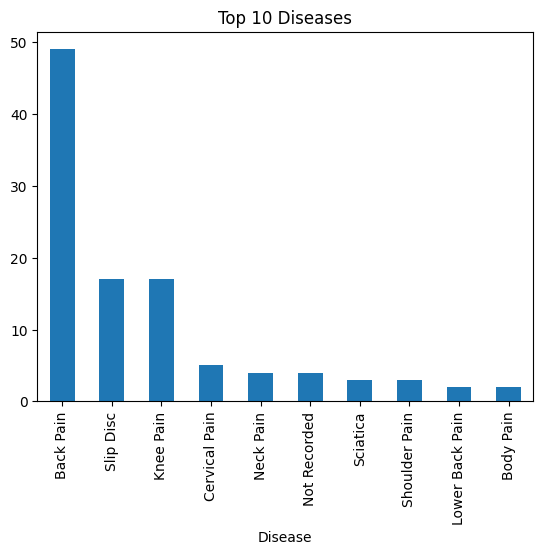

In [ ]:
##Bar Graph of Disease
master["Disease"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Diseases")
plt.show()

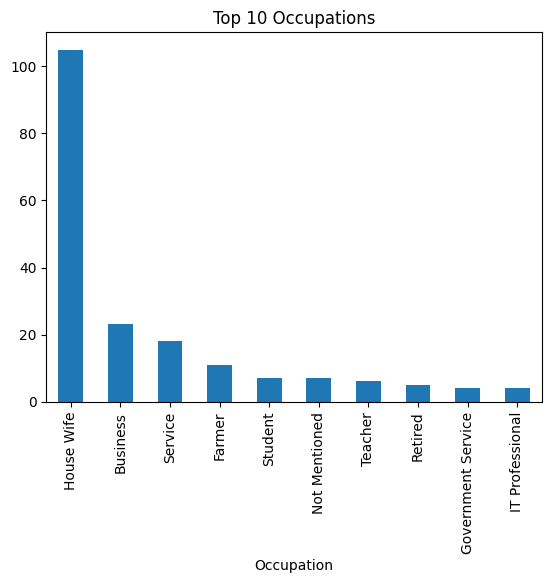

In [115]:
##Bar graph of Occupation
master["Occupation"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Occupations")
plt.show()

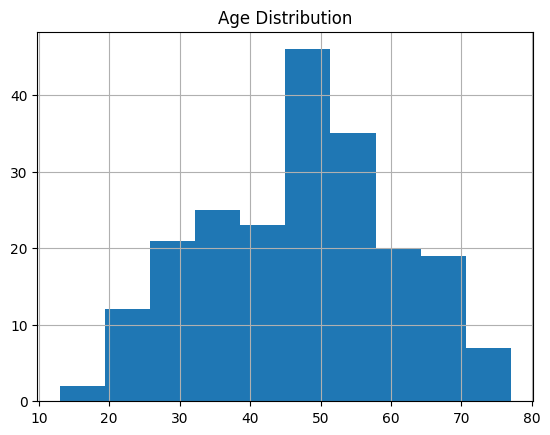

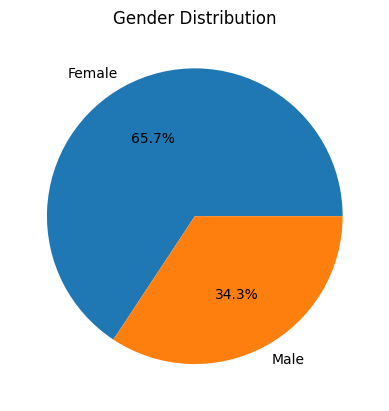

In [117]:
##Age distribution(Hist Graph)
master["Age"].hist()
plt.title("Age Distribution")
plt.show()

##Age percentage
import matplotlib.pyplot as plt

master["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()